<a href="https://colab.research.google.com/github/vivekchavan2401/CSL701-CE04_Machine-Learning-Lab/blob/main/Copy_of_ML_Experiment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name :Vivek Vikas Chavan

Batch :CE01


Roll Number :CE04



Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction on the Breast Cancer Wisconsin (Diagnostic) dataset, visualize the high-dimensional feature space in a reduced 2D plane, and evaluate its impact on classification performance.

## Objectives

1. To understand the concepts of dimensionality reduction, feature correlation, and Principal Component Analysis.

2. To preprocess, clean, and scale high-dimensional real-world data using StandardScaler.

3. To implement PCA using Python to compress feature dimensions from 30 continuous features down to 2 principal components.

4. To calculate and plot the explained variance ratio and cumulative explained variance.

5. To visualize the transformed 2D dataset and analyze class separability.

6. To evaluate and compare classification model performance (e.g., Logistic Regression) before and after applying PCA.

# Relevant Theory

### Support Vector Machine

Principal Component Analysis (PCA)Principal Component Analysis (PCA) is an unsupervised machine learning technique used for dimensionality reduction. It transforms a dataset containing a large set of correlated features into a smaller set of uncorrelated variables called Principal Components ($PCs$), while preserving as much data variance as possible.

Mathematical Steps:

1. Standardization: Scale each feature to have a mean of 0 ($\mu = 0$) and standard deviation of 1 ($\sigma = 1$).

2. Covariance Matrix: Compute the covariance matrix $C$ to quantify feature correlations:$$C = \frac{1}{n-1} X^T X$$

3. Eigen decomposition: Compute eigenvalues ($\lambda$) and eigenvectors ($v$) of matrix $C$:$$C v = \lambda v$$

    * Eigenvectors represent the direction of the principal axes.
    * Eigenvalues indicate the amount of variance along those axes.
4. Projection: Project original data $X$ onto top $k$ principal component directions $W$:$$X_{\text{pca}} = X \cdot W$$

###Dataset Information


1. Dataset Name: Breast Cancer Wisconsin (Diagnostic) Dataset

2. Kaggle Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

3. Classes: 2 binary classes (Malignant [$M$] and Benign [$B$])

4. Features: 30 continuous features computed from digitized images of fine needle aspirates (FNA) of a breast mass (e.g., radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, concavity_mean, etc.).

5. Non-Feature Columns: id (identifier) and Unnamed: 32 (empty column).

# Task 1: Import Libraries and Load Dataset

Import core Python libraries (numpy, pandas, matplotlib, seaborn, sklearn) and load data.csv obtained from Kaggle.

---

In [1]:
# Task 1: Import Libraries and Load Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Load the Breast Cancer Wisconsin (Diagnostic) dataset.
# Place data.csv in the same folder as this notebook.
data = pd.read_csv("data.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", data.shape)
display(data.head())


Dataset loaded successfully.
Dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Task 2: Explore the Dataset

Inspect missing values, view dataset summary statistics, check column data types, and inspect target class distributions (diagnosis).

Dataset shape: (569, 33)

--- Missing Values ---
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst       

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,569.0,NaN,NaN,NaN,30371831.432337,125020585.612224,8670.0,869218.0,906024.0,8813129.0,911320502.0
diagnosis,569,2,B,357,NaN,NaN,NaN,NaN,NaN,NaN,NaN
radius_mean,569.0,NaN,NaN,NaN,14.127292,3.524049,6.981,11.7,13.37,15.78,28.11
texture_mean,569.0,NaN,NaN,NaN,19.289649,4.301036,9.71,16.17,18.84,21.8,39.28
perimeter_mean,569.0,NaN,NaN,NaN,91.969033,24.298981,43.79,75.17,86.24,104.1,188.5
area_mean,569.0,NaN,NaN,NaN,654.889104,351.914129,143.5,420.3,551.1,782.7,2501.0
smoothness_mean,569.0,NaN,NaN,NaN,0.09636,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634
compactness_mean,569.0,NaN,NaN,NaN,0.104341,0.052813,0.01938,0.06492,0.09263,0.1304,0.3454
concavity_mean,569.0,NaN,NaN,NaN,0.088799,0.07972,0.0,0.02956,0.06154,0.1307,0.4268
concave points_mean,569.0,NaN,NaN,NaN,0.048919,0.038803,0.0,0.02031,0.0335,0.074,0.2012



--- Diagnosis Class Distribution ---
diagnosis
B    357
M    212
Name: count, dtype: int64

--- Diagnosis Class Distribution (%) ---
diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64


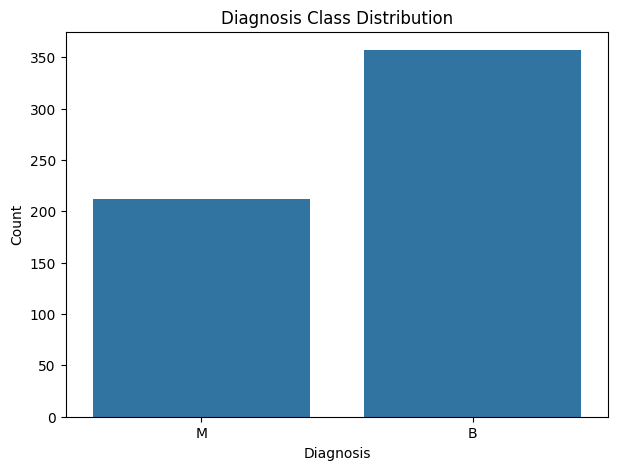

In [2]:
# Task 2: Explore the Dataset

print("Dataset shape:", data.shape)

print("\n--- Missing Values ---")
print(data.isnull().sum())

print("\n--- Data Types ---")
print(data.dtypes)

print("\n--- Summary Statistics ---")
display(data.describe(include="all").T)

print("\n--- Diagnosis Class Distribution ---")
print(data["diagnosis"].value_counts())

print("\n--- Diagnosis Class Distribution (%) ---")
print((data["diagnosis"].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(7, 5))
sns.countplot(data=data, x="diagnosis")
plt.title("Diagnosis Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()


# Task 3: Data Cleaning and Feature/Target Selection

Drop metadata columns (id and Unnamed: 32). Convert the categorical target column (diagnosis: 'M'/'B') into numerical values (1/0) and separate feature matrix $X$ (30 features) from label vector $y$.   

In [3]:
# Task 3: Data Cleaning and Feature/Target Selection

# Remove metadata columns if they are present.
columns_to_drop = [col for col in ["id", "Unnamed: 32"] if col in data.columns]
clean_data = data.drop(columns=columns_to_drop).copy()

# Convert diagnosis: M = 1 (Malignant), B = 0 (Benign).
if "diagnosis" not in clean_data.columns:
    raise KeyError("The dataset must contain a 'diagnosis' column.")

clean_data["diagnosis"] = clean_data["diagnosis"].map({"M": 1, "B": 0})

if clean_data["diagnosis"].isnull().any():
    raise ValueError("Unexpected values found in the 'diagnosis' column.")

# Separate features and target.
X = clean_data.drop(columns=["diagnosis"])
y = clean_data["diagnosis"].astype(int)

# Ensure all features are numeric.
X = X.apply(pd.to_numeric, errors="coerce")

# Handle any missing numeric values using column medians.
if X.isnull().any().any():
    X = X.fillna(X.median())

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Number of features:", X.shape[1])
print("\nTarget mapping: Malignant (M) = 1, Benign (B) = 0")
print(y.value_counts().sort_index())

display(X.head())
display(y.head())


Feature matrix shape: (569, 30)
Target vector shape: (569,)
Number of features: 30

Target mapping: Malignant (M) = 1, Benign (B) = 0
diagnosis
0    357
1    212
Name: count, dtype: int64


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,diagnosis
0,1
1,1
2,1
3,1
4,1


# Task 4: Standardize Features

Apply StandardScaler to transform all 30 numeric features so they have zero mean and unit variance ($\mu=0, \sigma=1$).

In [4]:
# Task 4: Standardize Features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Standardization completed.")
print("Scaled feature matrix shape:", X_scaled.shape)
print("Mean of first 5 scaled features:", np.round(X_scaled[:, :5].mean(axis=0), 6))
print("Standard deviation of first 5 scaled features:",
      np.round(X_scaled[:, :5].std(axis=0), 6))


Standardization completed.
Scaled feature matrix shape: (569, 30)
Mean of first 5 scaled features: [-0.  0. -0. -0. -0.]
Standard deviation of first 5 scaled features: [1. 1. 1. 1. 1.]


# Task 5: Implement PCA (30D to 2D)

Use sklearn.decomposition.PCA to reduce feature dimensions from 30 down to 2 principal components ($PC_1$ and $PC_2$).

In [5]:
# Task 5: Implement PCA (30D to 2D)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("PCA completed successfully.")
print("Original feature dimensions:", X_scaled.shape[1])
print("Reduced dimensions:", X_pca.shape[1])

pca_data = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

display(pca_data.head())


PCA completed successfully.
Original feature dimensions: 30
Reduced dimensions: 2


,PC1,PC2
0,9.192837,1.948583
1,2.387802,-3.768172
2,5.733896,-1.075174
3,7.122953,10.275589
4,3.935302,-1.948072


# Task 6: Analyze Explained Variance Ratio

Compute and print the variance explained by $PC_1$ and $PC_2$, along with the cumulative variance retained.


PC1 explained variance: 44.27%
PC2 explained variance: 18.97%
Cumulative variance retained by PC1 + PC2: 63.24%


,Principal Component,Explained Variance Ratio,Explained Variance (%),Cumulative Variance (%)
0,PC1,0.442720,44.272026,44.272026
1,PC2,0.189712,18.971182,63.243208


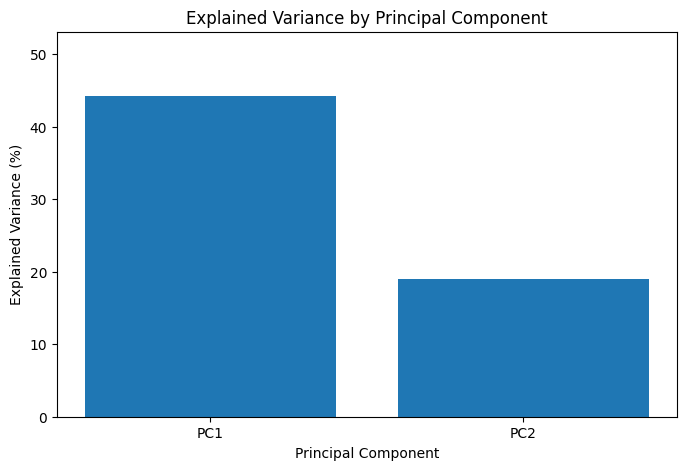

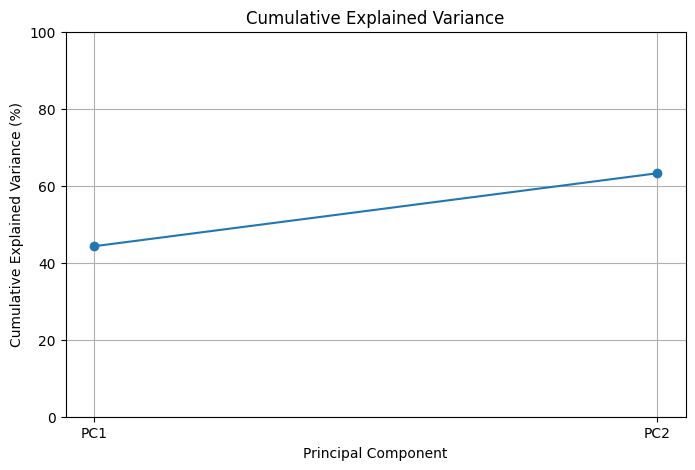

In [6]:
# Task 6: Analyze Explained Variance Ratio

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"PC1 explained variance: {explained_variance[0] * 100:.2f}%")
print(f"PC2 explained variance: {explained_variance[1] * 100:.2f}%")
print(f"Cumulative variance retained by PC1 + PC2: {cumulative_variance[1] * 100:.2f}%")

variance_table = pd.DataFrame({
    "Principal Component": ["PC1", "PC2"],
    "Explained Variance Ratio": explained_variance,
    "Explained Variance (%)": explained_variance * 100,
    "Cumulative Variance (%)": cumulative_variance * 100
})

display(variance_table)

plt.figure(figsize=(8, 5))
plt.bar(["PC1", "PC2"], explained_variance * 100)
plt.title("Explained Variance by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.ylim(0, max(explained_variance * 100) * 1.2)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    ["PC1", "PC2"],
    cumulative_variance * 100,
    marker="o"
)
plt.title("Cumulative Explained Variance")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance (%)")
plt.ylim(0, 100)
plt.grid(True)
plt.show()


# Task 7: Visualize PCA Transformed Boundary / Scatter Plot

Create a 2D scatter plot with $PC_1$ on the x-axis and $PC_2$ on the y-axis, hue-coded by tumor diagnosis (Malignant vs. Benign).

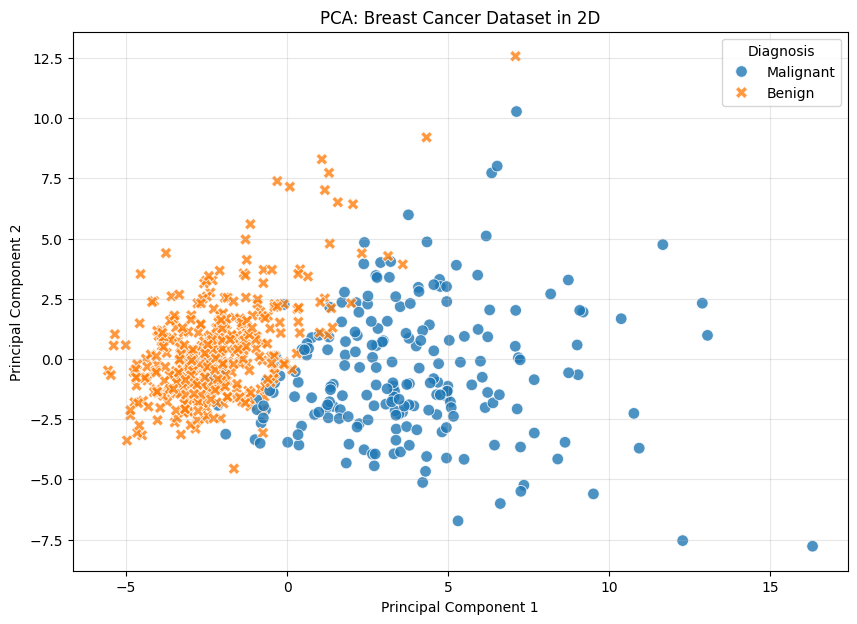

In [7]:
# Task 7: Visualize PCA Transformed Boundary / Scatter Plot

pca_plot_data = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Diagnosis": y.map({0: "Benign", 1: "Malignant"}).values
})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_plot_data,
    x="PC1",
    y="PC2",
    hue="Diagnosis",
    style="Diagnosis",
    s=70,
    alpha=0.8
)

plt.title("PCA: Breast Cancer Dataset in 2D")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Diagnosis")
plt.grid(True, alpha=0.3)
plt.show()


# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

Split the original scaled 30-feature dataset into training and testing sets. Train a Logistic Regression model and obtain baseline performance metrics.

In [8]:
# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

# Split the original standardized 30-feature dataset.
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

log_reg_raw = LogisticRegression(
    max_iter=5000,
    random_state=42
)

log_reg_raw.fit(X_train_raw, y_train_raw)
y_pred_raw = log_reg_raw.predict(X_test_raw)

raw_accuracy = accuracy_score(y_test_raw, y_pred_raw)

print(f"Baseline Logistic Regression Accuracy: {raw_accuracy * 100:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_raw, y_pred_raw))

print("\nClassification Report:")
print(
    classification_report(
        y_test_raw,
        y_pred_raw,
        target_names=["Benign", "Malignant"],
        digits=4
    )
)


Baseline Logistic Regression Accuracy: 96.49%

Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9595    0.9861    0.9726        72
   Malignant     0.9750    0.9286    0.9512        42

    accuracy                         0.9649       114
   macro avg     0.9672    0.9573    0.9619       114
weighted avg     0.9652    0.9649    0.9647       114



# Task 9: Train Classifier on PCA Transformed Data (2 Features)

Split the 2-component PCA dataset into training and testing sets. Train a Logistic Regression model using only $PC_1$ and $PC_2$.

In [9]:
# Task 9: Train Classifier on PCA Transformed Data (2 Features)

# Use the same train/test split indices as Task 8 for a fair comparison.
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

log_reg_pca = LogisticRegression(
    max_iter=5000,
    random_state=42
)

log_reg_pca.fit(X_train_pca, y_train_pca)
y_pred_pca = log_reg_pca.predict(X_test_pca)

pca_accuracy = accuracy_score(y_test_pca, y_pred_pca)

print(f"PCA Logistic Regression Accuracy: {pca_accuracy * 100:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_pca, y_pred_pca))

print("\nClassification Report:")
print(
    classification_report(
        y_test_pca,
        y_pred_pca,
        target_names=["Benign", "Malignant"],
        digits=4
    )
)


PCA Logistic Regression Accuracy: 93.86%

Confusion Matrix:
[[71  1]
 [ 6 36]]

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9221    0.9861    0.9530        72
   Malignant     0.9730    0.8571    0.9114        42

    accuracy                         0.9386       114
   macro avg     0.9475    0.9216    0.9322       114
weighted avg     0.9408    0.9386    0.9377       114



# Task 10: Compare Classifier Performance

Compare the performance of the model before PCA (30 features) vs. after PCA (2 components) using:   

*   Accuracy Score
*   Confusion Matrix
*   Classification Report (Precision, Recall, F1-Score)  



MODEL PERFORMANCE COMPARISON
Accuracy before PCA (30 features): 96.49%
Accuracy after PCA (2 features):   93.86%
Accuracy difference:                2.63 percentage points


,Model,Number of Features,Accuracy (%)
0,Logistic Regression - 30 Features,30,96.491228
1,Logistic Regression - 2 PCA Features,2,93.859649


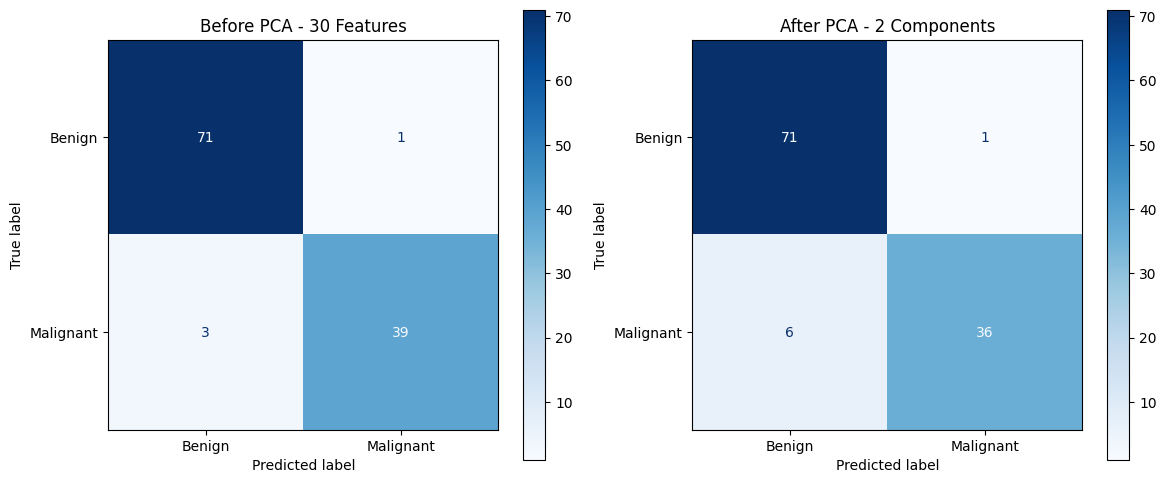


--- Classification Report: Before PCA ---
              precision    recall  f1-score   support

      Benign     0.9595    0.9861    0.9726        72
   Malignant     0.9750    0.9286    0.9512        42

    accuracy                         0.9649       114
   macro avg     0.9672    0.9573    0.9619       114
weighted avg     0.9652    0.9649    0.9647       114

--- Classification Report: After PCA ---
              precision    recall  f1-score   support

      Benign     0.9221    0.9861    0.9530        72
   Malignant     0.9730    0.8571    0.9114        42

    accuracy                         0.9386       114
   macro avg     0.9475    0.9216    0.9322       114
weighted avg     0.9408    0.9386    0.9377       114



In [10]:
# Task 10: Compare Classifier Performance

print("=" * 70)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 70)

print(f"Accuracy before PCA (30 features): {raw_accuracy * 100:.2f}%")
print(f"Accuracy after PCA (2 features):   {pca_accuracy * 100:.2f}%")
print(f"Accuracy difference:                {(raw_accuracy - pca_accuracy) * 100:.2f} percentage points")

# Comparison table.
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression - 30 Features",
        "Logistic Regression - 2 PCA Features"
    ],
    "Number of Features": [X_scaled.shape[1], X_pca.shape[1]],
    "Accuracy": [raw_accuracy, pca_accuracy]
})

comparison["Accuracy (%)"] = comparison["Accuracy"] * 100
display(comparison.drop(columns=["Accuracy"]))

# Confusion matrices.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_raw,
    y_pred_raw,
    display_labels=["Benign", "Malignant"],
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Before PCA - 30 Features")

ConfusionMatrixDisplay.from_predictions(
    y_test_pca,
    y_pred_pca,
    display_labels=["Benign", "Malignant"],
    cmap="Blues",
    ax=axes[1]
)
axes[1].set_title("After PCA - 2 Components")

plt.tight_layout()
plt.show()

print("\n--- Classification Report: Before PCA ---")
print(
    classification_report(
        y_test_raw,
        y_pred_raw,
        target_names=["Benign", "Malignant"],
        digits=4
    )
)

print("--- Classification Report: After PCA ---")
print(
    classification_report(
        y_test_pca,
        y_pred_pca,
        target_names=["Benign", "Malignant"],
        digits=4
    )
)


# Conclusion

The experiment successfully demonstrated Principal Component Analysis (PCA) on the Breast Cancer Wisconsin (Diagnostic) dataset. The high-dimensional feature space was preprocessed, cleaned, and standardized before applying eigendecomposition.

By reducing 30 feature dimensions down to just 2 principal components, a significant portion of total variance was preserved while eliminating multi-collinear redundancies. Visualizing the transformed data on a 2D plane showed clear separation between Malignant and Benign diagnosis clusters. Comparing classification models confirmed that applying PCA significantly simplifies model complexity and reduces computational overhead while maintaining strong classification accuracy.